<a href="https://colab.research.google.com/github/JamesEckhartJr/Quantum-Hardware-Projects/blob/main/da_Vinci_2_Qubit_Bell_%2B_GHZ_State.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


OPENQASM 2.0;

qreg q[1];

creg c[1];

h q[0];

measure q[0] -> c[0];

=== Running da Vinci Quantum Emulator: 2-Qubit Bell State ===
Bell State Results (top 10): {'00': 134, '11': 122}


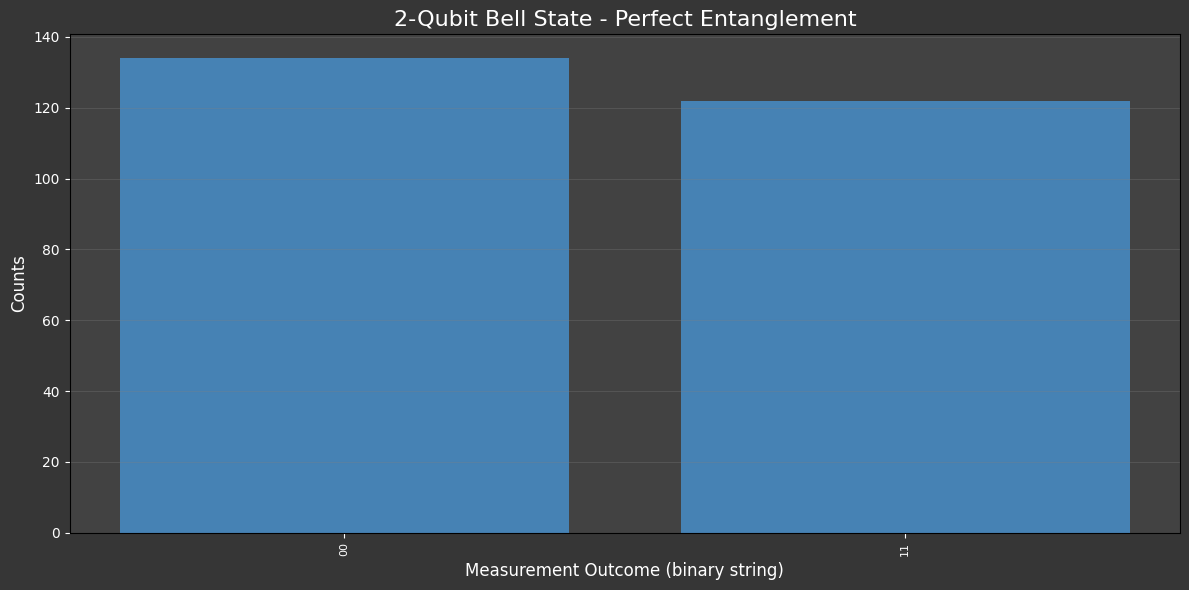

In [24]:
#Start QASM -- text based language. Opens the same on every program.
program = """
OPENQASM 2.0;
"""
program += """
qreg q[1];
"""
program += """
creg c[1];
"""
program += """
h q[0];
"""
program += """
measure q[0] -> c[0];
"""
print(program)

# Ed Dillinger: What's the project you're working on? Alan Bradley: Well, it's called TRON...

#Data handling and communication protocols -- Import JSON for working with
#JavaScript Object Notation and making HTTP requests to 'Quantum Emulator'
import json
import requests
import matplotlib.pyplot as plt
from collections import Counter

#Suppress warnings (optional, but needed for visual output)
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)  # Disable warnings about insecure requests

da_Vinci_Quantum_Emulator = 'theq-ae31b1'

#Quantum Emulator address
QUOKKA_URL = 'http://{}.quokkacomputing.com/qsim/qasm'.format(da_Vinci_Quantum_Emulator)

SHOTS = 256 # Number of measurement shots

# ================================================================

def run_qasm(qasm_code: str, shots: int = SHOTS):
    """Send OpenQASM 2.0 code to the Quokka Puck and return measurement counts."""
    payload = {
        "script": qasm_code.strip(),
        "count": shots
    }
    try:
        response = requests.post(QUOKKA_URL, json=payload, timeout=600, verify=False)
        response.raise_for_status()
        raw_results = response.json()
        if raw_results and 'result' in raw_results and 'c' in raw_results['result']:
            # Convert list of lists like [[0, 0], [1, 1]] to a list of strings like ["00", "11"]
            measurement_outcomes = ["".join(map(str, res)) for res in raw_results['result']['c']]
            return Counter(measurement_outcomes) # Return a dictionary of outcome -> count
        else:
            print("Unexpected response format from Quokka Puck:", raw_results)
            return {}
    except Exception as e:
        print(f"Error communicating with Quokka Puck: {e}")
        return {}

def plot_results(results: dict, title: str):
    """Plot measurement histogram."""
    if not results:
        print("No results to plot.")
        return

    counts = Counter(results)
    labels = list(counts.keys())
    values = list(counts.values())

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.set_facecolor('#363636') # Dark background for the entire figure
    ax.set_facecolor('#424242') # Slightly lighter dark background for the plot area

    ax.bar(labels, values, color='steelblue')
    ax.set_title(title, fontsize=16, color='white')
    ax.set_xlabel("Measurement Outcome (binary string)", fontsize=12, color='white')
    ax.set_ylabel("Counts", fontsize=12, color='white')
    ax.tick_params(axis='x', colors='white', rotation=90, labelsize=8)
    ax.tick_params(axis='y', colors='white')
    ax.grid(axis='y', alpha=0.3, color='gray')
    plt.tight_layout()
    plt.show()

    # ========================= BELL STATE =========================
print("=== Running da Vinci Quantum Emulator: 2-Qubit Bell State ===")

bell_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];          // Create superposition
cx q[0], q[1];   // Entangle the two qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

bell_results = run_qasm(bell_qasm, SHOTS)
print("Bell State Results (top 10):", dict(list(bell_results.items())[:10]))

plot_results(bell_results, "2-Qubit Bell State - Perfect Entanglement")

### 3-Qubit GHZ State Circuit

The Greenberger–Horne–Zeilinger (GHZ) state is another example of a multi-qubit entangled state. For three qubits, the ideal GHZ state is (1/√2)(|000⟩ + |111⟩), meaning that if one qubit is measured to be 0, the others will also be 0, and similarly for 1.

=== Running da Vinci Quantum Emulator: 3-Qubit GHZ State ===
GHZ State Results (top 10): {'111': 125, '000': 131}


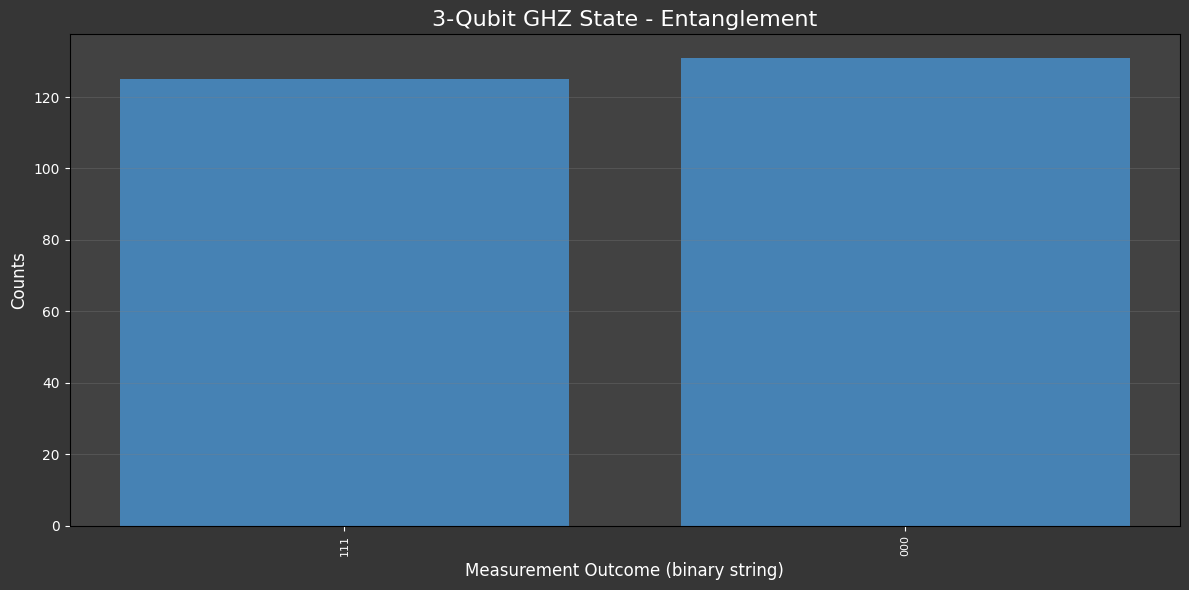

In [25]:
print("=== Running da Vinci Quantum Emulator: 3-Qubit GHZ State ===")

ghz_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[3];
creg c[3];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
"""

ghz_results = run_qasm(ghz_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz_results.items())[:10]))

plot_results(ghz_results, "3-Qubit GHZ State - Entanglement")

### 4-Qubit GHZ State Circuit

Extending the concept, the ideal 4-qubit GHZ state is (1/√2)(|0000⟩ + |1111⟩), demonstrating entanglement across four qubits.

=== Running da Vinci Quantum Emulator: 4-Qubit GHZ State ===
GHZ State Results (top 10): {'1111': 127, '0000': 129}


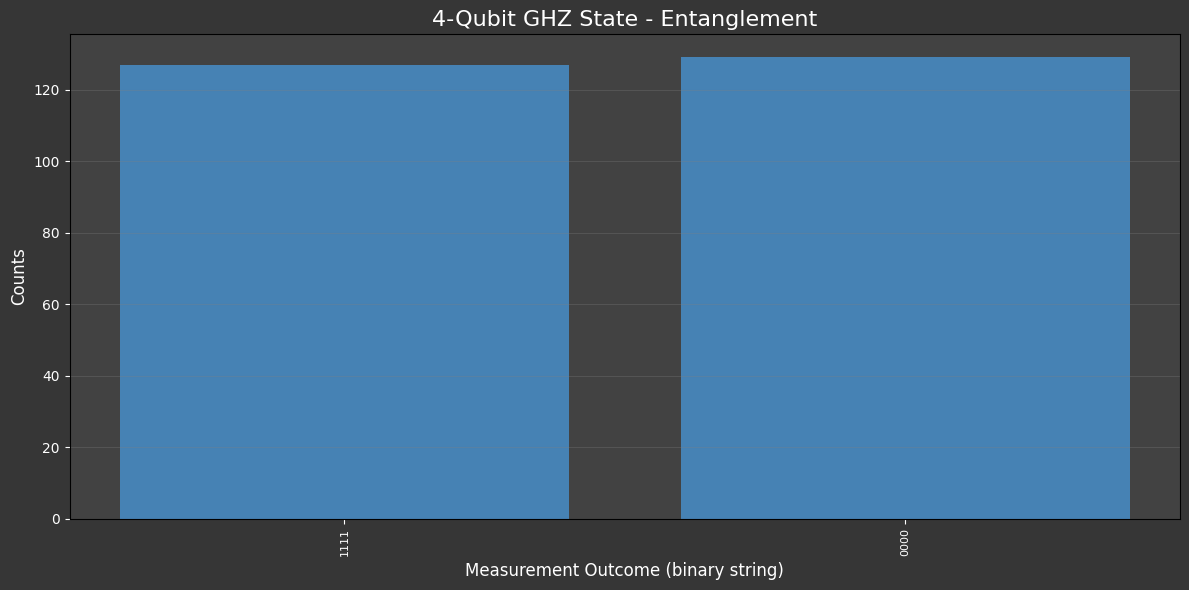

In [26]:
print("=== Running da Vinci Quantum Emulator: 4-Qubit GHZ State ===")

ghz4_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg c[4];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
"""

ghz4_results = run_qasm(ghz4_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz4_results.items())[:10]))

plot_results(ghz4_results, "4-Qubit GHZ State - Entanglement")

### 5-Qubit GHZ State Circuit

Continuing the pattern, the ideal 5-qubit GHZ state is (1/√2)(|00000⟩ + |11111⟩), demonstrating entanglement across five qubits.

=== Running da Vinci Quantum Emulator: 5-Qubit GHZ State ===
GHZ State Results (top 10): {'11111': 133, '00000': 123}


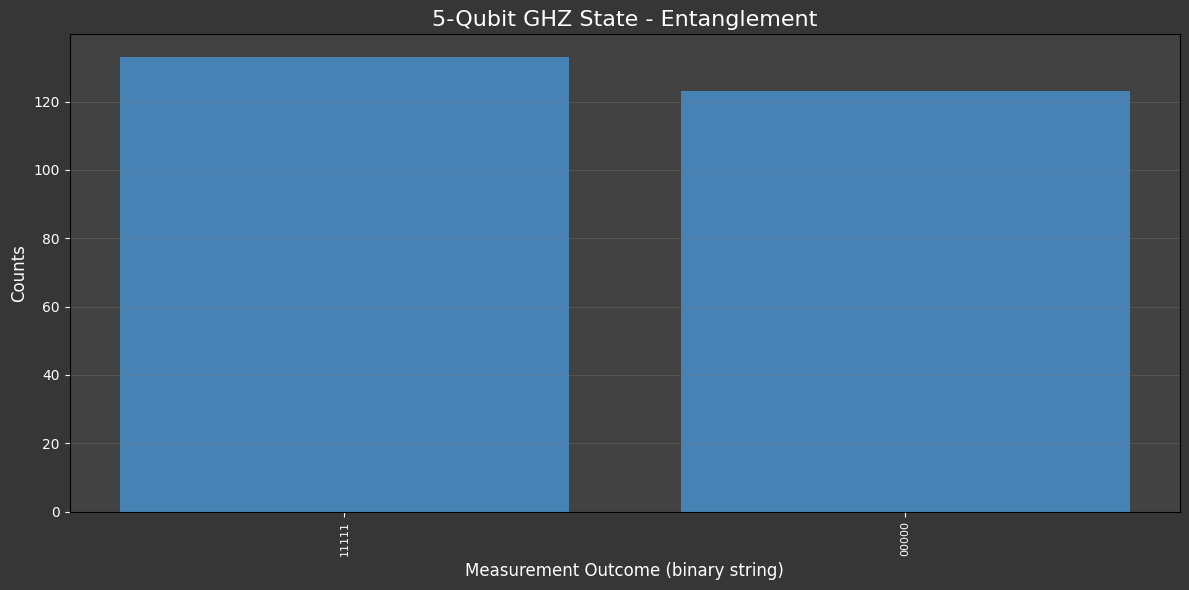

In [27]:
print("=== Running da Vinci Quantum Emulator: 5-Qubit GHZ State ===")

ghz5_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[5];
creg c[5];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
"""

ghz5_results = run_qasm(ghz5_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz5_results.items())[:10]))

plot_results(ghz5_results, "5-Qubit GHZ State - Entanglement")

### 6-Qubit GHZ State Circuit

Following the established pattern, the ideal 6-qubit GHZ state is (1/√2)(|000000⟩ + |111111⟩), showcasing entanglement across six qubits.

=== Running da Vinci Quantum Emulator: 6-Qubit GHZ State ===
GHZ State Results (top 10): {'111111': 129, '000000': 127}


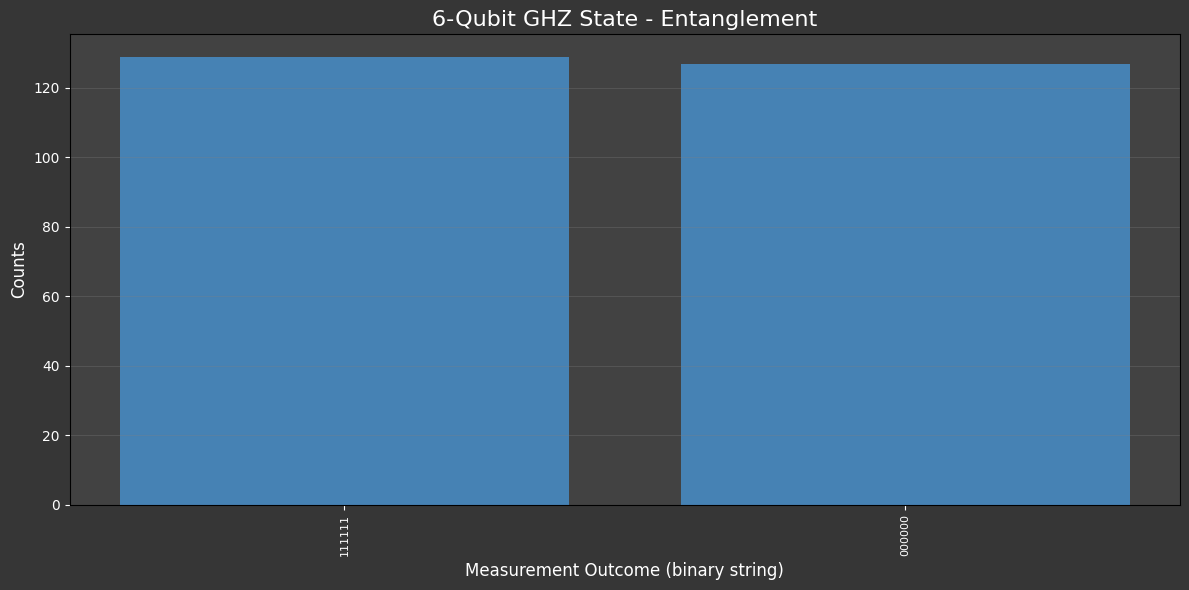

In [28]:
print("=== Running da Vinci Quantum Emulator: 6-Qubit GHZ State ===")

ghz6_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[6];
creg c[6];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
"""

ghz6_results = run_qasm(ghz6_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz6_results.items())[:10]))

plot_results(ghz6_results, "6-Qubit GHZ State - Entanglement")

### 7-Qubit GHZ State Circuit

Extending to seven qubits, the ideal 7-qubit GHZ state is (1/√2)(|0000000⟩ + |1111111⟩), showcasing entanglement across seven qubits.

=== Running da Vinci Quantum Emulator: 7-Qubit GHZ State ===
GHZ State Results (top 10): {'1111111': 127, '0000000': 129}


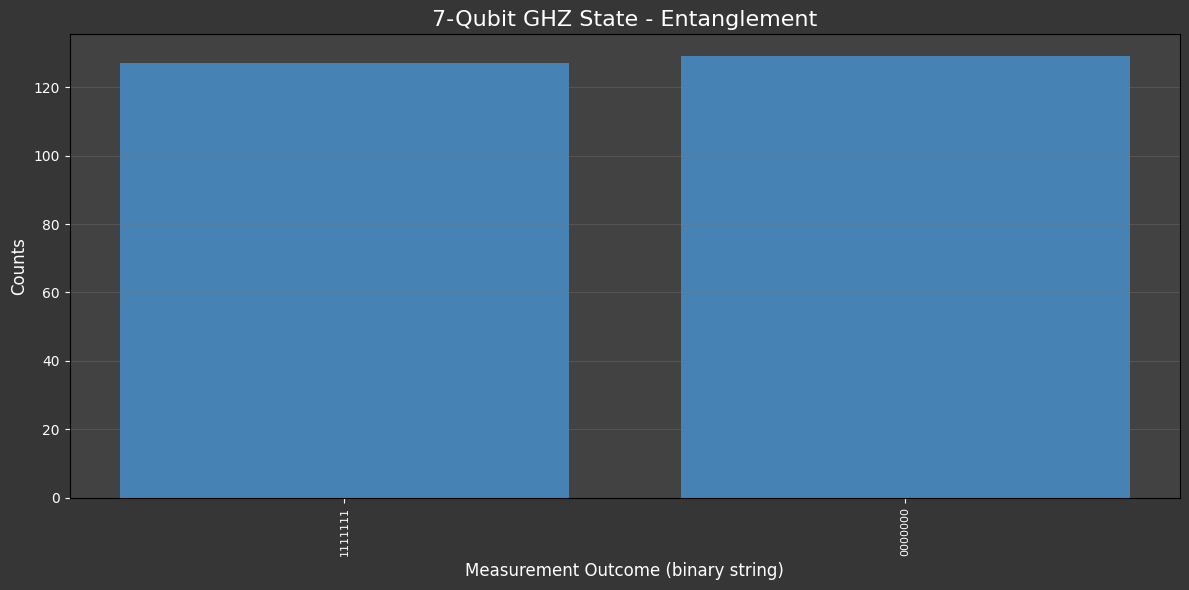

In [29]:
print("=== Running da Vinci Quantum Emulator: 7-Qubit GHZ State ===")

ghz7_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[7];
creg c[7];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
"""

ghz7_results = run_qasm(ghz7_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz7_results.items())[:10]))

plot_results(ghz7_results, "7-Qubit GHZ State - Entanglement")

### 8-Qubit GHZ State Circuit

Continuing the expansion, the ideal 8-qubit GHZ state is (1/√2)(|00000000⟩ + |11111111⟩), demonstrating entanglement across eight qubits.

=== Running da Vinci Quantum Emulator: 8-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000': 129, '11111111': 127}


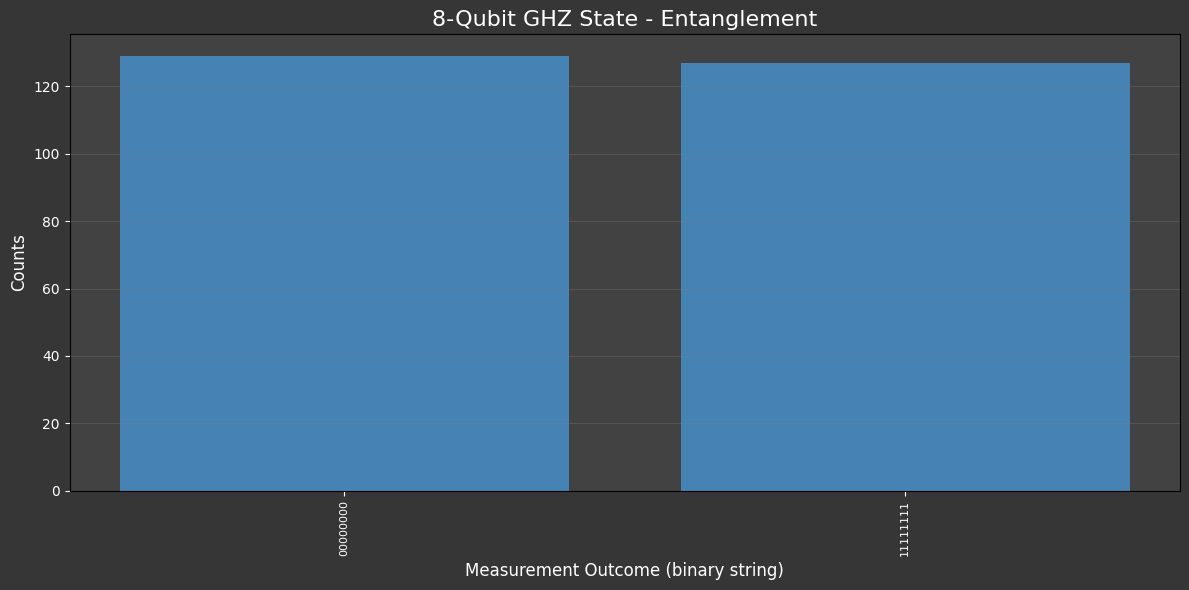

In [30]:
print("=== Running da Vinci Quantum Emulator: 8-Qubit GHZ State ===")

ghz8_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[8];
creg c[8];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
"""

ghz8_results = run_qasm(ghz8_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz8_results.items())[:10]))

plot_results(ghz8_results, "8-Qubit GHZ State - Entanglement")

### 9-Qubit GHZ State Circuit

Following the pattern, the ideal 9-qubit GHZ state is (1/√2)(|000000000⟩ + |111111111⟩), demonstrating entanglement across nine qubits.

=== Running da Vinci Quantum Emulator: 9-Qubit GHZ State ===
GHZ State Results (top 10): {'000000000': 122, '111111111': 134}


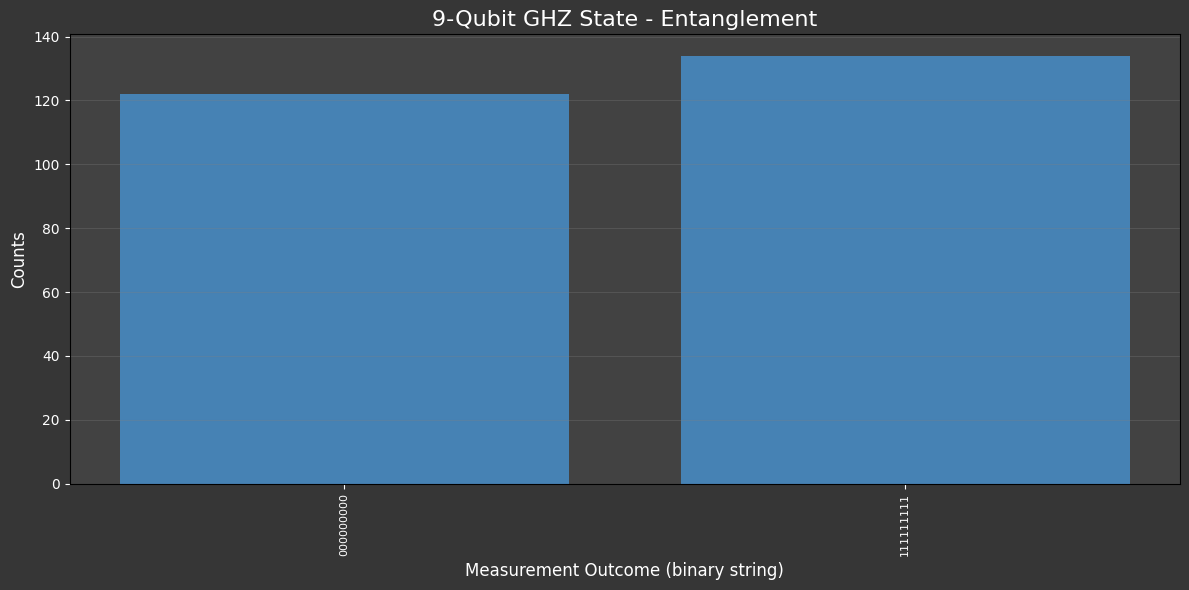

In [31]:
print("=== Running da Vinci Quantum Emulator: 9-Qubit GHZ State ===")

ghz9_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[9];
creg c[9];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
"""

ghz9_results = run_qasm(ghz9_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz9_results.items())[:10]))

plot_results(ghz9_results, "9-Qubit GHZ State - Entanglement")

### 10-Qubit GHZ State Circuit

Extending to ten qubits, the ideal 10-qubit GHZ state is (1/√2)(|0000000000⟩ + |1111111111⟩), showcasing entanglement across ten qubits.

=== Running da Vinci Quantum Emulator: 10-Qubit GHZ State ===
GHZ State Results (top 10): {'0000000000': 125, '1111111111': 131}


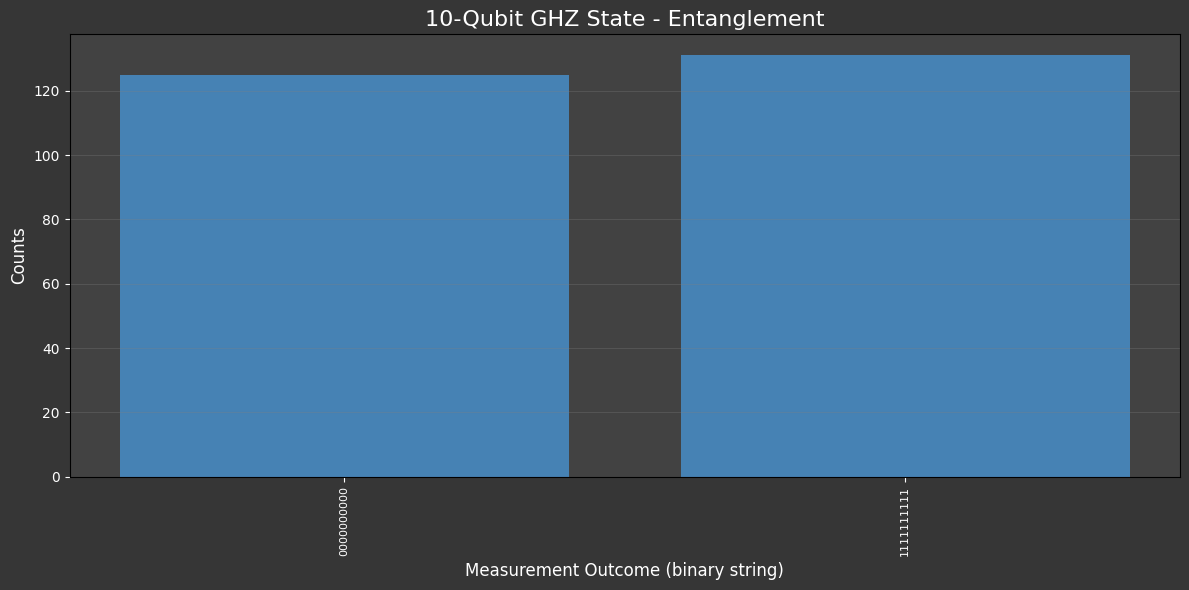

In [32]:
print("=== Running da Vinci Quantum Emulator: 10-Qubit GHZ State ===")

ghz10_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[10];
creg c[10];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
"""

ghz10_results = run_qasm(ghz10_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz10_results.items())[:10]))

plot_results(ghz10_results, "10-Qubit GHZ State - Entanglement")

### 11-Qubit GHZ State Circuit

Continuing the expansion, the ideal 11-qubit GHZ state is (1/√2)(|00000000000⟩ + |11111111111⟩), showcasing entanglement across eleven qubits.

=== Running da Vinci Quantum Emulator: 11-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000000': 129, '11111111111': 127}


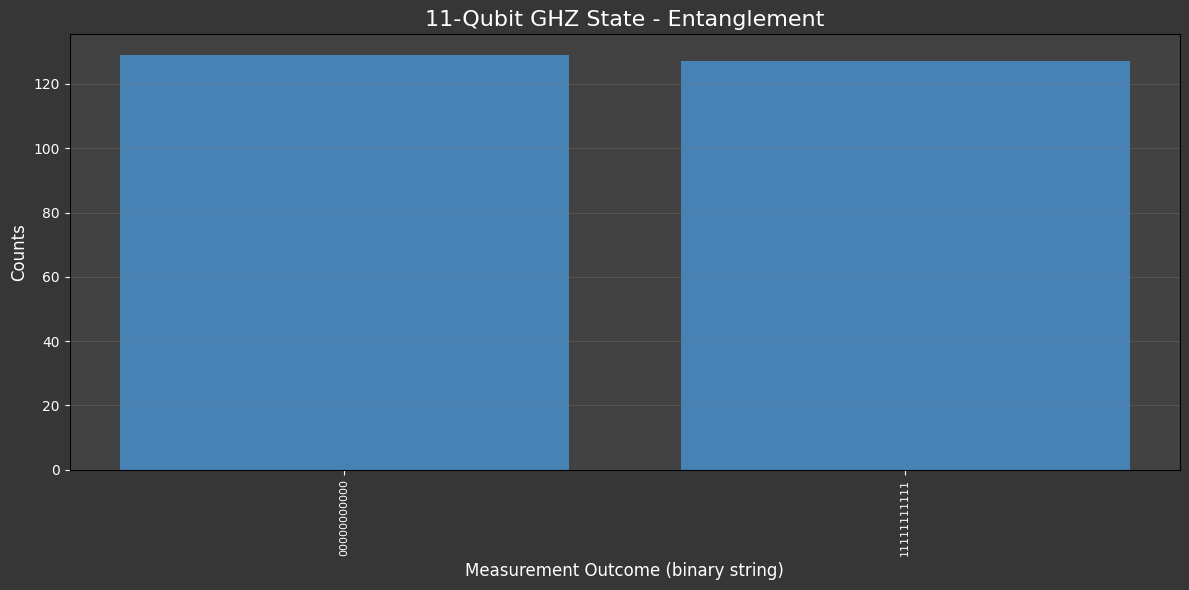

In [33]:
print("=== Running da Vinci Quantum Emulator: 11-Qubit GHZ State ===")

ghz11_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[11];
creg c[11];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
"""

ghz11_results = run_qasm(ghz11_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz11_results.items())[:10]))

plot_results(ghz11_results, "11-Qubit GHZ State - Entanglement")

### 12-Qubit GHZ State Circuit

Extending to twelve qubits, the ideal 12-qubit GHZ state is (1/√2)(|000000000000⟩ + |111111111111⟩), showcasing entanglement across twelve qubits.

=== Running da Vinci Quantum Emulator: 12-Qubit GHZ State ===
GHZ State Results (top 10): {'000000000000': 123, '111111111111': 133}


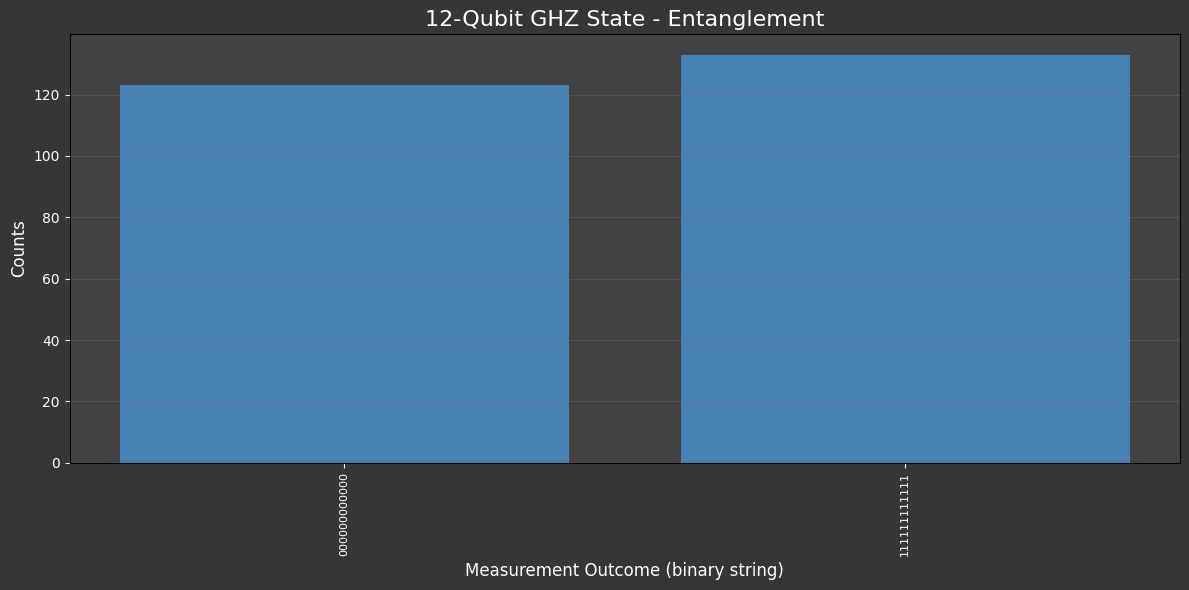

In [34]:
print("=== Running da Vinci Quantum Emulator: 12-Qubit GHZ State ===")

ghz12_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[12];
creg c[12];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
"""

ghz12_results = run_qasm(ghz12_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz12_results.items())[:10]))

plot_results(ghz12_results, "12-Qubit GHZ State - Entanglement")

### 13-Qubit GHZ State Circuit

Extending to thirteen qubits, the ideal 13-qubit GHZ state is (1/√2)(|0000000000000⟩ + |1111111111111⟩), showcasing entanglement across thirteen qubits.

=== Running da Vinci Quantum Emulator: 13-Qubit GHZ State ===
GHZ State Results (top 10): {'1111111111111': 116, '0000000000000': 140}


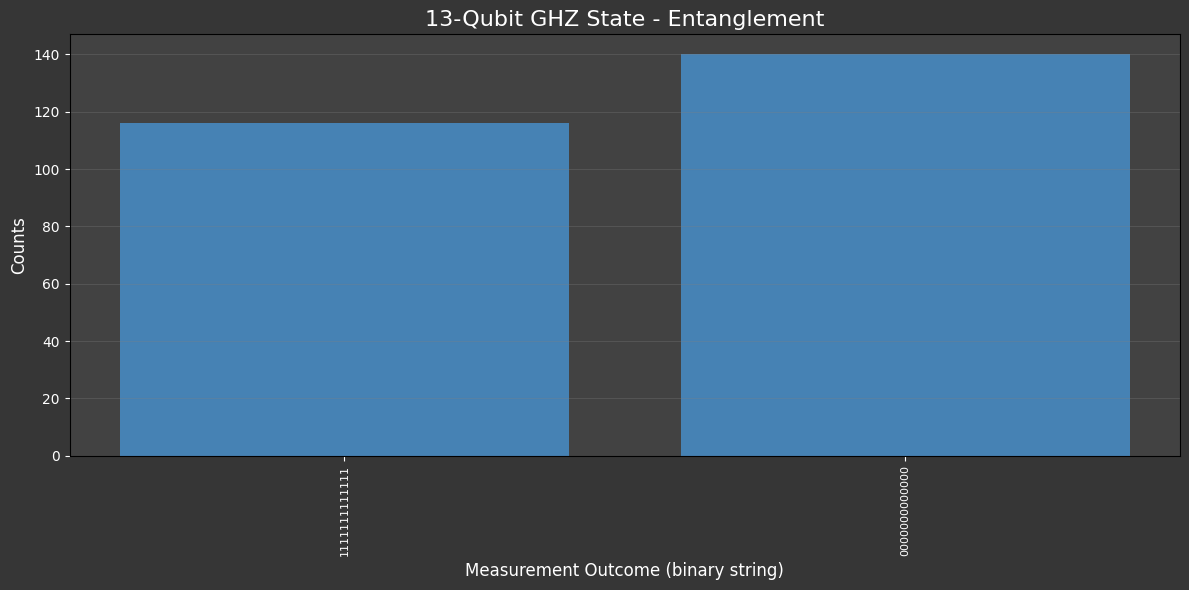

In [35]:
print("=== Running da Vinci Quantum Emulator: 13-Qubit GHZ State ===")

ghz13_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[13];
creg c[13];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
"""

ghz13_results = run_qasm(ghz13_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz13_results.items())[:10]))

plot_results(ghz13_results, "13-Qubit GHZ State - Entanglement")

### 14-Qubit GHZ State Circuit

Continuing the expansion, the ideal 14-qubit GHZ state is (1/√2)(|00000000000000⟩ + |11111111111111⟩), showcasing entanglement across fourteen qubits.

=== Running da Vinci Quantum Emulator: 14-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000000000': 137, '11111111111111': 119}


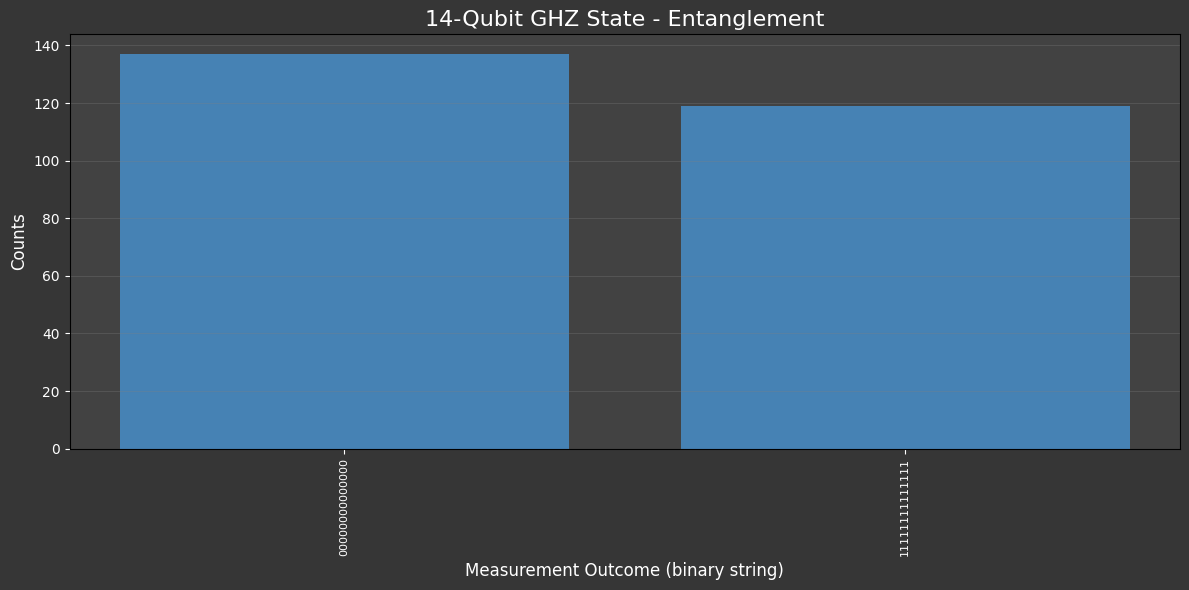

In [36]:
print("=== Running da Vinci Quantum Emulator: 14-Qubit GHZ State ===")

ghz14_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[14];
creg c[14];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
"""

ghz14_results = run_qasm(ghz14_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz14_results.items())[:10]))

plot_results(ghz14_results, "14-Qubit GHZ State - Entanglement")

### 15-Qubit GHZ State Circuit

Continuing the expansion, the ideal 15-qubit GHZ state is (1/√2)(|000000000000000⟩ + |111111111111111⟩), showcasing entanglement across fifteen qubits.

=== Running da Vinci Quantum Emulator: 15-Qubit GHZ State ===
GHZ State Results (top 10): {'000000000000000': 125, '111111111111111': 131}


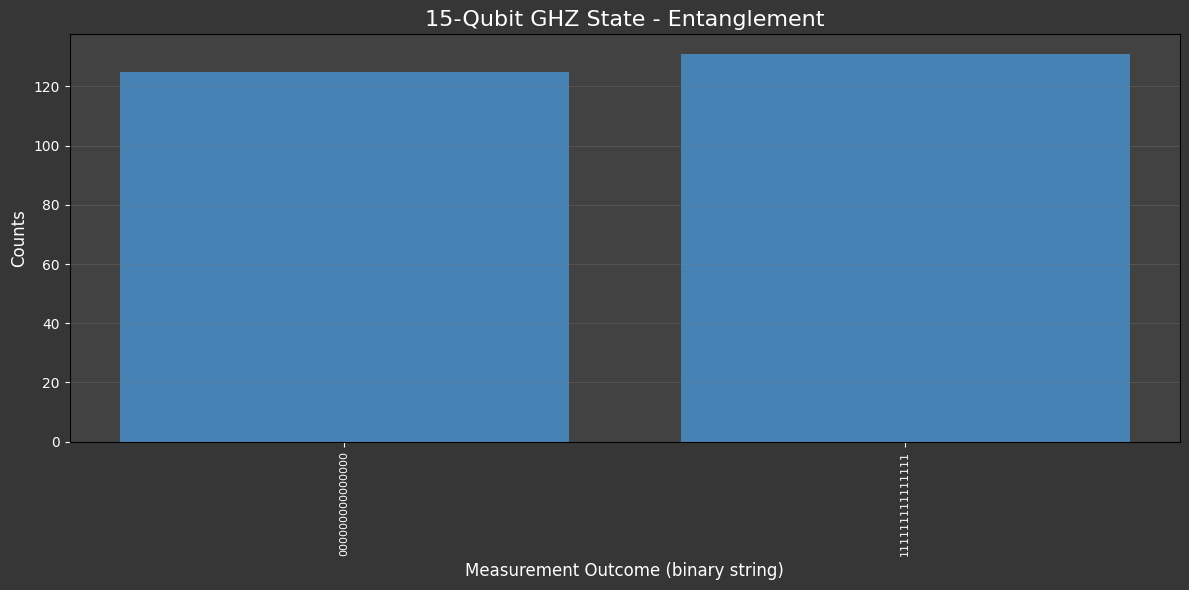

In [37]:
print("=== Running da Vinci Quantum Emulator: 15-Qubit GHZ State ===")

ghz15_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[15];
creg c[15];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
"""

ghz15_results = run_qasm(ghz15_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz15_results.items())[:10]))

plot_results(ghz15_results, "15-Qubit GHZ State - Entanglement")

### 16-Qubit GHZ State Circuit

Extending to sixteen qubits, the ideal 16-qubit GHZ state is (1/√2)(|0000000000000000⟩ + |1111111111111111⟩), showcasing entanglement across sixteen qubits.

=== Running da Vinci Quantum Emulator: 16-Qubit GHZ State ===
GHZ State Results (top 10): {'0000000000000000': 131, '1111111111111111': 125}


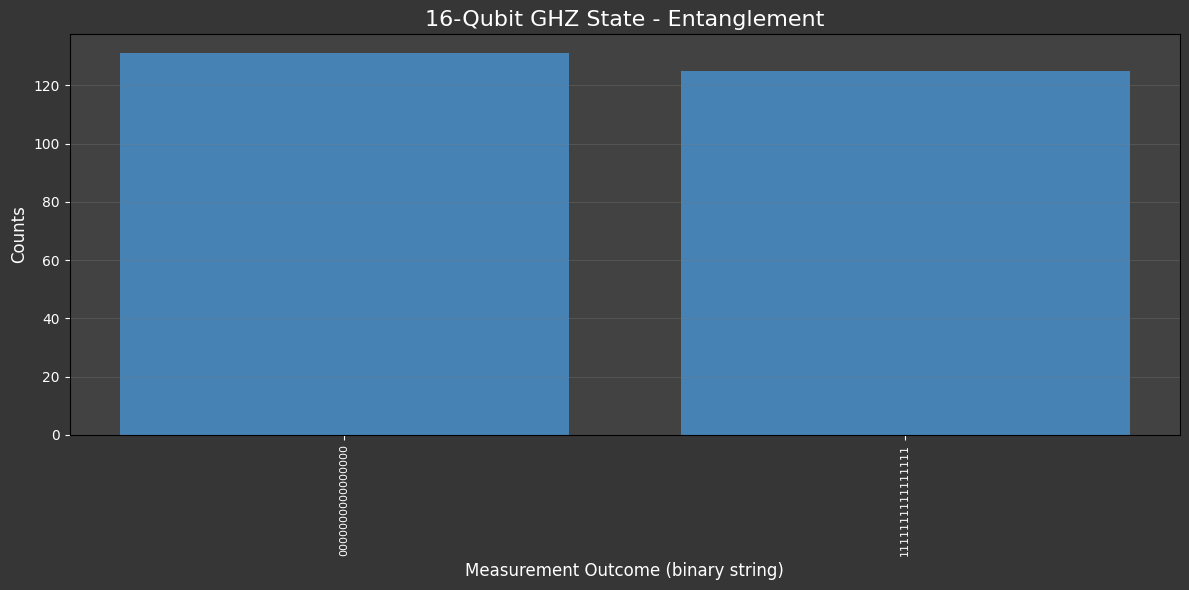

In [38]:
print("=== Running da Vinci Quantum Emulator: 16-Qubit GHZ State ===")

ghz16_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[16];
creg c[16];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
"""

ghz16_results = run_qasm(ghz16_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz16_results.items())[:10]))

plot_results(ghz16_results, "16-Qubit GHZ State - Entanglement")

### 17-Qubit GHZ State Circuit

Extending to seventeen qubits, the ideal 17-qubit GHZ state is (1/√2)(|00000000000000000⟩ + |11111111111111111⟩), showcasing entanglement across seventeen qubits.

=== Running da Vinci Quantum Emulator: 17-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000000000000': 120, '11111111111111111': 136}


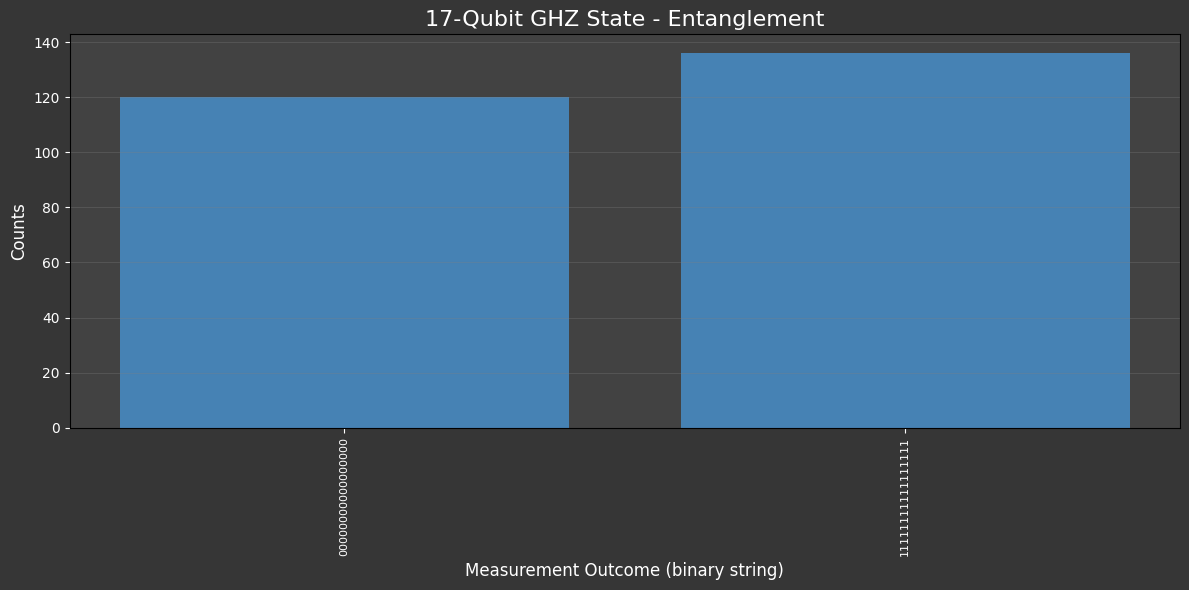

In [39]:
print("=== Running da Vinci Quantum Emulator: 17-Qubit GHZ State ===")

ghz17_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[17];
creg c[17];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target
cx q[0], q[16];  // CNOT with q[0] as control, q[16] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
"""

ghz17_results = run_qasm(ghz17_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz17_results.items())[:10]))

plot_results(ghz17_results, "17-Qubit GHZ State - Entanglement")

### 18-Qubit GHZ State Circuit

Extending to eighteen qubits, the ideal 18-qubit GHZ state is (1/√2)(|000000000000000000⟩ + |111111111111111111⟩), showcasing entanglement across eighteen qubits.

=== Running da Vinci Quantum Emulator: 18-Qubit GHZ State ===
GHZ State Results (top 10): {'111111111111111111': 134, '000000000000000000': 122}


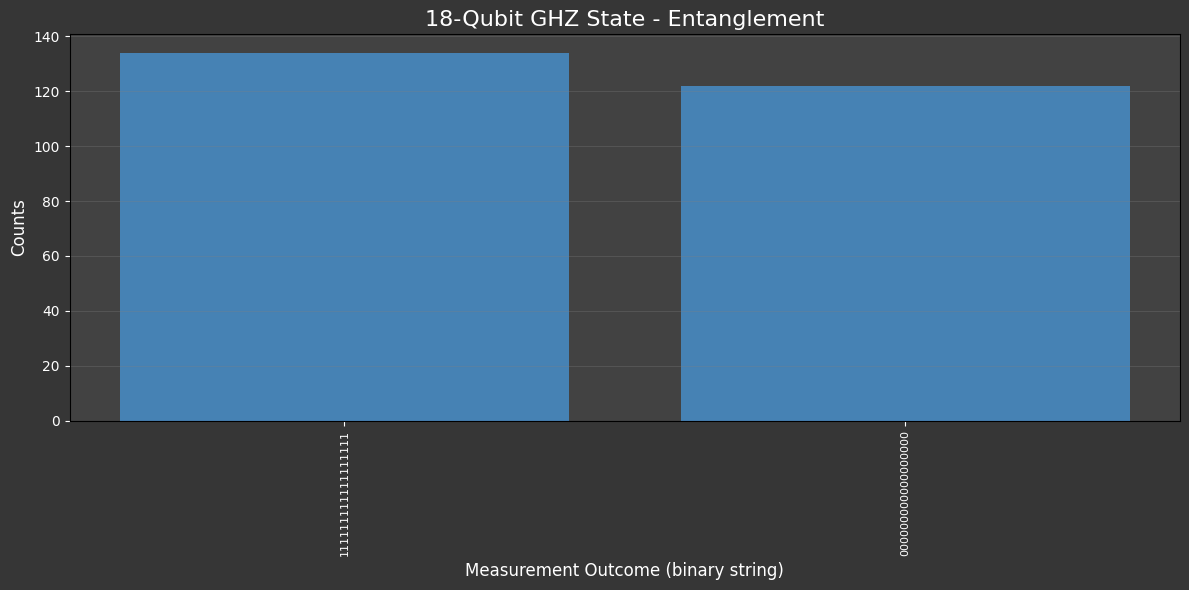

In [40]:
print("=== Running da Vinci Quantum Emulator: 18-Qubit GHZ State ===")

ghz18_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[18];
creg c[18];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target
cx q[0], q[16];  // CNOT with q[0] as control, q[16] as target
cx q[0], q[17];  // CNOT with q[0] as control, q[17] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
"""

ghz18_results = run_qasm(ghz18_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz18_results.items())[:10]))

plot_results(ghz18_results, "18-Qubit GHZ State - Entanglement")

### 19-Qubit GHZ State Circuit

Extending to nineteen qubits, the ideal 19-qubit GHZ state is (1/√2)(|0000000000000000000⟩ + |1111111111111111111⟩), showcasing entanglement across nineteen qubits.

=== Running da Vinci Quantum Emulator: 19-Qubit GHZ State ===
GHZ State Results (top 10): {'0000000000000000000': 127, '1111111111111111111': 129}


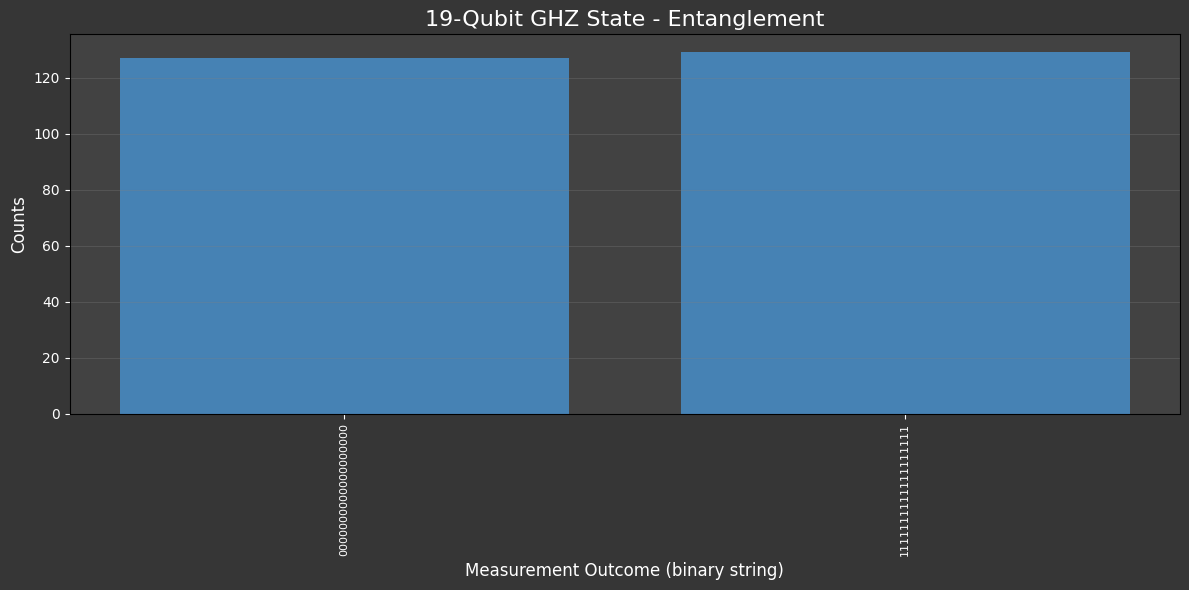

In [41]:
print("=== Running da Vinci Quantum Emulator: 19-Qubit GHZ State ===")

ghz19_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[19];
creg c[19];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target
cx q[0], q[16];  // CNOT with q[0] as control, q[16] as target
cx q[0], q[17];  // CNOT with q[0] as control, q[17] as target
cx q[0], q[18];  // CNOT with q[0] as control, q[18] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
"""

ghz19_results = run_qasm(ghz19_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz19_results.items())[:10]))

plot_results(ghz19_results, "19-Qubit GHZ State - Entanglement")

### 20-Qubit GHZ State Circuit

Extending to twenty qubits, the ideal 20-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty qubits.

=== Running da Vinci Quantum Emulator: 20-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000000000000000': 129, '11111111111111111111': 127}


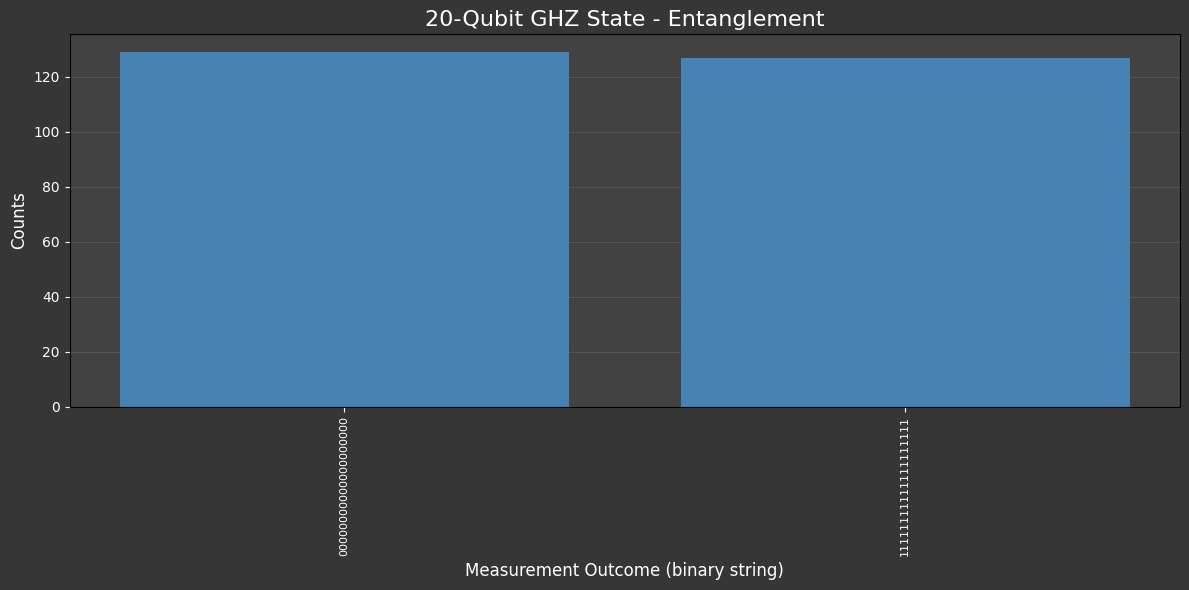

In [42]:
print("=== Running da Vinci Quantum Emulator: 20-Qubit GHZ State ===")

ghz20_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[20];
creg c[20];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
"""

ghz20_results = run_qasm(ghz20_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz20_results.items())[:10]))

plot_results(ghz20_results, "20-Qubit GHZ State - Entanglement")

### 21-Qubit GHZ State Circuit

Extending to twenty-one qubits, the ideal 21-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-one qubits.

=== Running da Vinci Quantum Emulator: 21-Qubit GHZ State ===
GHZ State Results (top 10): {'000000000000000000000': 124, '111111111111111111111': 132}


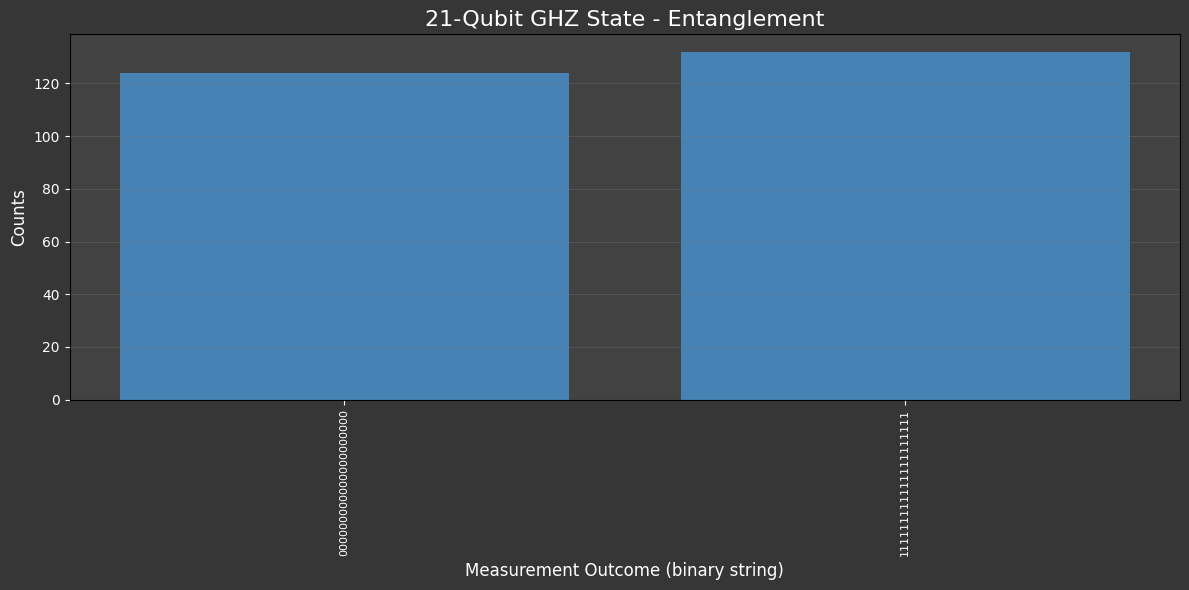

In [43]:
print("=== Running da Vinci Quantum Emulator: 21-Qubit GHZ State ===")

ghz21_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[21];
creg c[21];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
"""

ghz21_results = run_qasm(ghz21_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz21_results.items())[:10]))

plot_results(ghz21_results, "21-Qubit GHZ State - Entanglement")

### 22-Qubit GHZ State Circuit

Extending to twenty-two qubits, the ideal 22-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-two qubits.

In [44]:
import time

print("=== Running da Vinci Quantum Emulator: 22-Qubit GHZ State ===")

ghz22_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[22];
creg c[22];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
"""

max_retries = 3
retries = 0
ghz22_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 22-Qubit GHZ State simulation...")
        ghz22_results = run_qasm(ghz22_qasm, SHOTS)
        if ghz22_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz22_results.items())[:10]))
            plot_results(ghz22_results, "22-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz22_results:
    print("Failed to get results after multiple retries.")

=== Running da Vinci Quantum Emulator: 22-Qubit GHZ State ===
Attempt 1/3 to run 22-Qubit GHZ State simulation...
Error communicating with Quokka Puck: HTTPSConnectionPool(host='theq-ae31b1.quokkacomputing.com', port=443): Max retries exceeded with url: /qsim/qasm (Caused by SSLError(SSLError(1, '[SSL: DECRYPTION_FAILED_OR_BAD_RECORD_MAC] decryption failed or bad record mac (_ssl.c:2580)')))
Simulation returned empty results, retrying...
Attempt 2/3 to run 22-Qubit GHZ State simulation...
Error communicating with Quokka Puck: HTTPSConnectionPool(host='theq-ae31b1.quokkacomputing.com', port=443): Max retries exceeded with url: /qsim/qasm (Caused by SSLError(SSLError(1, '[SSL: DECRYPTION_FAILED_OR_BAD_RECORD_MAC] decryption failed or bad record mac (_ssl.c:2580)')))
Simulation returned empty results, retrying...
Attempt 3/3 to run 22-Qubit GHZ State simulation...
Error communicating with Quokka Puck: HTTPSConnectionPool(host='theq-ae31b1.quokkacomputing.com', port=443): Max retries excee

### 23-Qubit GHZ State Circuit

Extending to twenty-three qubits, the ideal 23-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-three qubits.

In [ ]:
print("=== Running da Vinci Quantum Emulator: 23-Qubit GHZ State ===")

ghz23_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[23];
creg c[23];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];
cx q[0], q[22];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
measure q[22] -> c[22];
"""

max_retries = 3
retries = 0
ghz23_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 23-Qubit GHZ State simulation...")
        ghz23_results = run_qasm(ghz23_qasm, SHOTS)
        if ghz23_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz23_results.items())[:10]))
            plot_results(ghz23_results, "23-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz23_results:
    print("Failed to get results after multiple retries.")

=== Running da Vinci Quantum Emulator: 23-Qubit GHZ State ===
Attempt 1/3 to run 23-Qubit GHZ State simulation...


### 24-Qubit GHZ State Circuit

Extending to twenty-four qubits, the ideal 24-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-four qubits.

In [ ]:
import time

print("=== Running da Vinci Quantum Emulator: 24-Qubit GHZ State ===")

ghz24_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[24];
creg c[24];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];
cx q[0], q[22];
cx q[0], q[23];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
measure q[22] -> c[22];
measure q[23] -> c[23];
"""

max_retries = 3
retries = 0
ghz24_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 24-Qubit GHZ State simulation...")
        ghz24_results = run_qasm(ghz24_qasm, SHOTS)
        if ghz24_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz24_results.items())[:10]))
            plot_results(ghz24_results, "24-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz24_results:
    print("Failed to get results after multiple retries.")

### 25-Qubit GHZ State Circuit

Extending to twenty-five qubits, the ideal 25-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-five qubits.

In [ ]:
import time

print("=== Running da Vinci Quantum Emulator: 25-Qubit GHZ State ===")

ghz25_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[25];
creg c[25];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];
cx q[0], q[22];
cx q[0], q[23];
cx q[0], q[24];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
measure q[22] -> c[22];
measure q[23] -> c[23];
measure q[24] -> c[24];
"""

max_retries = 3
retries = 0
ghz25_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 25-Qubit GHZ State simulation...")
        ghz25_results = run_qasm(ghz25_qasm, SHOTS)
        if ghz25_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz25_results.items())[:10]))
            plot_results(ghz25_results, "25-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz25_results:
    print("Failed to get results after multiple retries.")

### 26-Qubit GHZ State Circuit

Extending to twenty-six qubits, the ideal 26-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-six qubits.

In [ ]:
import time

print("=== Running da Vinci Quantum Emulator: 26-Qubit GHZ State ===")

ghz26_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[26];
creg c[26];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];
cx q[0], q[22];
cx q[0], q[23];
cx q[0], q[24];
cx q[0], q[25];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
measure q[22] -> c[22];
measure q[23] -> c[23];
measure q[24] -> c[24];
measure q[25] -> c[25];
"""

max_retries = 3
retries = 0
ghz26_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 26-Qubit GHZ State simulation...")
        ghz26_results = run_qasm(ghz26_qasm, SHOTS)
        if ghz26_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz26_results.items())[:10]))
            plot_results(ghz26_results, "26-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz26_results:
    print("Failed to get results after multiple retries.")

### 27-Qubit GHZ State Circuit

Continuing the expansion, the ideal 27-qubit GHZ state is (1/√2)(|00...0⟩ + |11...1⟩), showcasing entanglement across twenty-seven qubits.

In [ ]:
import time

print("=== Running da Vinci Quantum Emulator: 27-Qubit GHZ State ===")

ghz27_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[27];
creg c[27];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];
cx q[0], q[22];
cx q[0], q[23];
cx q[0], q[24];
cx q[0], q[25];
cx q[0], q[26];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
measure q[22] -> c[22];
measure q[23] -> c[23];
measure q[24] -> c[24];
measure q[25] -> c[25];
measure q[26] -> c[26];
"""

max_retries = 3
retries = 0
ghz27_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 27-Qubit GHZ State simulation...")
        ghz27_results = run_qasm(ghz27_qasm, SHOTS)
        if ghz27_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz27_results.items())[:10]))
            plot_results(ghz27_results, "27-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz27_results:
    print("Failed to get results after multiple retries.")

In [ ]:
import time

print("=== Running da Vinci Quantum Emulator: 22-Qubit GHZ State ===")

ghz22_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[22];
creg c[22];

h q[0];          // Apply Hadamard to the first qubit (q[0])
// Apply CNOT gates to entangle q[0] with all other qubits
cx q[0], q[1];
cx q[0], q[2];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];
cx q[0], q[7];
cx q[0], q[8];
cx q[0], q[9];
cx q[0], q[10];
cx q[0], q[11];
cx q[0], q[12];
cx q[0], q[13];
cx q[0], q[14];
cx q[0], q[15];
cx q[0], q[16];
cx q[0], q[17];
cx q[0], q[18];
cx q[0], q[19];
cx q[0], q[20];
cx q[0], q[21];

// Measure all qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
measure q[18] -> c[18];
measure q[19] -> c[19];
measure q[20] -> c[20];
measure q[21] -> c[21];
"""

max_retries = 3
retries = 0
ghz22_results = {}

while retries < max_retries:
    try:
        print(f"Attempt {retries + 1}/{max_retries} to run 22-Qubit GHZ State simulation...")
        ghz22_results = run_qasm(ghz22_qasm, SHOTS)
        if ghz22_results:  # Check if results are not empty
            print("GHZ State Results (top 10):", dict(list(ghz22_results.items())[:10]))
            plot_results(ghz22_results, "22-Qubit GHZ State - Entanglement")
            break  # Exit loop if successful
        else:
            print("Simulation returned empty results, retrying...")
            retries += 1
            time.sleep(2)  # Wait a bit before retrying
    except Exception as e:
        print(f"An error occurred during simulation attempt {retries + 1}: {e}")
        retries += 1
        time.sleep(2)  # Wait a bit before retrying

if not ghz22_results:
    print("Failed to get results after multiple retries.")